In [1]:
# # Run this and then restart the kernel at the start of each session to install
# # 'teotil3' in development mode
# !pip install -e /home/jovyan/projects/teotil3/

In [2]:
import contextily as cx
import geopandas as gpd
import matplotlib.pyplot as plt
import nivapy3 as nivapy
import pandas as pd
import teotil3 as teo
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from shapely.geometry import box

plt.style.use("ggplot")

In [3]:
eng = nivapy.da.connect_postgis()

Connection successful.


# TEOTIL3 for Lillestrøm kommune
# Notebook 01: Catchment maps

Lillestrøm Kommune are interested in TEOTIL3 results based on the recent Oslofjord modelling project. This notebook generates boundaries for the main catchments of interest and extracts point sources within these areas from the TEOTIL3 database. It also generates land cover proportions based on AR50.

## 1. Derive catchment boundaries

In [4]:
# Read catchment data
xl_path = r"../data/lillestrom_monitoring_sites.xlsx"
cat_df = pd.read_excel(xl_path, sheet_name="catch_outlets")
cat_df

,cat_id,regine,name,outlet_lon,outlet_lat,nve_area_km2,comment
0,1,002.CBA0,Sagelva,11.02384,59.95745,109,Tributary to Nitelva
1,2,002.CB0,Nitelva,11.07092,59.93806,484,Just upstream of confluence with Leira
2,3,002.CAA0,Leira,11.07367,59.93905,668,Just upstream of confluence with Nitelva
3,4,002.D2Z,Rømua,11.20984,59.99055,212,Single REGINE; no lakes; inputs only?
4,5,002.CAA0,Jeksla,11.09281,59.99753,17,Small sub-catchment of Leira; not resolved by ...
5,6,002.D3Z,Åa,11.28279,59.99649,131,Single REGINE; few lakes; inputs only?
6,7,002.C5,Gansåa,11.22130,59.86080,25,Not resolved by REGINE network


In [5]:
# Delineate catchments
cat_gdf = nivapy.spatial.derive_watershed_boundaries(
    cat_df,
    id_col="cat_id",
    xcol="outlet_lon",
    ycol="outlet_lat",
    crs="epsg:4326",
    min_size_km2=5,
    dem_res_m=40,
    buffer_km=None,
    temp_fold=None,
    reproject=False,
)

# Calculate area
cat_gdf["area_km2"] = cat_gdf.to_crs({"proj": "cea"}).geometry.area / 1e6

# Convert outlets to points
outlet_gdf = gpd.GeoDataFrame(
    cat_df,
    geometry=gpd.points_from_xy(
        cat_df["outlet_lon"], cat_df["outlet_lat"], crs="epsg:4326"
    ),
).to_crs("epsg:25833")

cat_gdf

Connection successful.


Looping over vassdragsområder:   0%|          | 0/1 [00:00<?, ?it/s]

Looping over outlets in vassdragsområder 002:   0%|          | 0/7 [00:00<?, ?it/s]

,cat_id,geometry,regine,name,outlet_lon,outlet_lat,nve_area_km2,comment,area_km2
0,1,"POLYGON ((273240 6654760, 273240 6654720, 2732...",002.CBA0,Sagelva,11.02384,59.95745,109,Tributary to Nitelva,108.970822
1,2,"POLYGON ((255960 6689560, 255960 6689480, 2558...",002.CB0,Nitelva,11.07092,59.93806,484,Just upstream of confluence with Leira,483.918446
2,3,"MULTIPOLYGON (((270920 6698040, 270920 6698000...",002.CAA0,Leira,11.07367,59.93905,668,Just upstream of confluence with Nitelva,668.050554
3,4,"MULTIPOLYGON (((291400 6657720, 291360 6657720...",002.D2Z,Rømua,11.20984,59.99055,212,Single REGINE; no lakes; inputs only?,211.868370
4,5,"POLYGON ((285320 6667880, 285320 6667840, 2852...",002.CAA0,Jeksla,11.09281,59.99753,17,Small sub-catchment of Leira; not resolved by ...,17.066204
5,6,"MULTIPOLYGON (((305320 6656440, 305320 6656480...",002.D3Z,Åa,11.28279,59.99649,131,Single REGINE; few lakes; inputs only?,130.697269
6,7,"POLYGON ((290800 6648280, 290800 6648240, 2907...",002.C5,Gansåa,11.22130,59.86080,25,Not resolved by REGINE network,25.341946


## 2. Get point inputs

### 2.1. Large wastewater sites (> 50 p.e.)

In [6]:
st_yr, end_yr = 2013, 2023
srcs = ["aquaculture", "industry", "large wastewater"]

df_list = []
for year in range(st_yr, end_yr + 1):
    for src in srcs:
        df_list.append(
            teo.io.get_raw_annual_point_data(
                eng,
                year,
                src,
                par_list=[
                    "totn_kg",
                    "din_kg",
                    "ton_kg",
                    "totp_kg",
                    "tdp_kg",
                    "tpp_kg",
                    "toc_kg",
                    "ss_kg",
                ],
            )
        )
pt_df = pd.concat(df_list, axis="rows")

# Convert outlet co-ords to lat/lon
pt_df["utm_zone"] = 33
pt_df = nivapy.spatial.utm_to_wgs84_dd(
    pt_df, zone="utm_zone", east="outlet_x_utm33", north="outlet_y_utm33"
)

# Assign to catchments
pt_df = (
    nivapy.spatial.identify_point_in_polygon(
        pt_df,
        cat_gdf,
        pt_col="site_id",
        poly_col="cat_id",
        lat_col="lat",
        lon_col="lon",
    )
    .dropna(subset="cat_id")
    .drop_duplicates()
)
pt_df["cat_id"] = pt_df["cat_id"].astype(int)

# Convert to Norwegian
pt_df["sector"] = pt_df["sector"].replace(
    {"Industry": "Industrianlegg", "Large wastewater": "Kommunalt avløp (>50 pe)"}
)

# Add catchment names
pt_df = pd.merge(
    pt_df, cat_df[["cat_id", "name"]], how="left", on="cat_id"
).sort_values(["cat_id", "site_id", "year"])

# Get unique outlet points
pt_gdf = (
    pt_df[
        [
            "cat_id",
            "name",
            "site_id",
            "site_name",
            "sector",
            "type",
            "site_x_utm33",
            "site_y_utm33",
            "outlet_x_utm33",
            "outlet_y_utm33",
        ]
    ]
    .drop_duplicates(subset="site_id")
    .sort_values(["cat_id", "site_id"])
)

# Mean annual discharges
avg_pt_df = pt_df[['site_id', 'TOTN_kg','TOTP_kg','TOC_kg','SS_kg']].groupby('site_id').mean().reset_index()
pt_gdf = pd.merge(pt_gdf, avg_pt_df, how='left', on='site_id')

# Convert to gdf
pt_gdf = gpd.GeoDataFrame(
    pt_gdf,
    geometry=gpd.points_from_xy(
        pt_gdf["outlet_x_utm33"], pt_gdf["outlet_y_utm33"], crs="epsg:25833"
    ),
)

pt_df.head()

,site_id,site_name,sector,type,site_x_utm33,site_y_utm33,outlet_x_utm33,outlet_y_utm33,year,regine,...,TON_kg,TOTN_kg,TOTP_kg,TPP_kg,SS_kg,utm_zone,lat,lon,cat_id,name
1,0301.0983.01,"Mariholtet sportsstue, renseanlegg",Kommunalt avløp (>50 pe),Naturbasert,271099.340373,6.646361e+06,271107.040376,6.646346e+06,2013,002.CBB5,...,0.9,10.5,0.5,0.3,10.0,33,59.890988,10.908055,1,Sagelva
20,0301.0983.01,"Mariholtet sportsstue, renseanlegg",Kommunalt avløp (>50 pe),Naturbasert,271099.340373,6.646361e+06,271107.040376,6.646346e+06,2014,002.CBB5,...,0.9,10.5,0.5,0.3,10.0,33,59.890988,10.908055,1,Sagelva
38,0301.0983.01,"Mariholtet sportsstue, renseanlegg",Kommunalt avløp (>50 pe),Naturbasert,271099.340373,6.646361e+06,271107.040376,6.646346e+06,2015,002.CBB5,...,0.9,10.5,0.5,0.3,10.0,33,59.890988,10.908055,1,Sagelva
56,0301.0983.01,"Mariholtet sportsstue, renseanlegg",Kommunalt avløp (>50 pe),Naturbasert,271099.340373,6.646361e+06,271107.040376,6.646346e+06,2016,002.CBB5,...,0.9,10.5,0.5,0.3,10.0,33,59.890988,10.908055,1,Sagelva
74,0301.0983.01,"Mariholtet sportsstue, renseanlegg",Kommunalt avløp (>50 pe),Naturbasert,271099.340373,6.646361e+06,271107.040376,6.646346e+06,2017,002.CBB5,...,0.9,10.5,0.5,0.3,10.0,33,59.890988,10.908055,1,Sagelva


In [7]:
# Get raw wastewater discharges with extra metadata
pt_id_list = pt_gdf["site_id"].tolist()
df_list = []
for year in range(st_yr, end_yr + 1):
    xl_path = f"/home/jovyan/shared/common/teotil3/point_data/{year}/large_wastewater_{year}_raw.xlsx"
    av_df = pd.read_excel(xl_path).query("anlegg_nr in @pt_id_list")
    df_list.append(av_df)
av_df = pd.concat(df_list, axis="rows").sort_values(["anlegg_nr", "year"])

In [8]:
# Save
pt_xl_path = r"../data/point_discharges.xlsx"
with pd.ExcelWriter(pt_xl_path) as writer:
    pt_gdf.drop(columns="geometry").to_excel(
        writer, sheet_name="point_locs", index=False
    )
    pt_df.to_excel(writer, sheet_name="all_point_discharges", index=False)
    av_df.to_excel(writer, sheet_name="wastewater_discharges", index=False)

### 2.2. Overflows

In [9]:
# Read overflow data
ov_xl_path = r"../data/lillestrom_wastewater_data.xlsx"
ov_df = pd.read_excel(ov_xl_path, sheet_name='overflows')

assert ov_df['overflow_id'].is_unique

# Convert outlet co-ords to lat/lon
ov_df["utm_zone"] = 32
ov_df = nivapy.spatial.utm_to_wgs84_dd(
    ov_df, zone="utm_zone", east="utm32_east", north="utm32_north"
)

# Assign to catchments
ov_df = (
    nivapy.spatial.identify_point_in_polygon(
        ov_df,
        cat_gdf,
        pt_col="overflow_id",
        poly_col="cat_id",
        lat_col="lat",
        lon_col="lon",
    )
    .dropna(subset="cat_id")
    .drop_duplicates()
)
ov_df["cat_id"] = ov_df["cat_id"].astype(int)

# Convert to gdf
ov_gdf = gpd.GeoDataFrame(
    ov_df,
    geometry=gpd.points_from_xy(
        ov_df["utm32_east"], ov_df["utm32_north"], crs="epsg:25832"
    ),
).to_crs("epsg:25833")

### 2.3. Small wastewater sites (spredt)

In [10]:
# Read spredt data
sp_xl_path = r"../data/lillestrom_wastewater_data.xlsx"
sp_df = pd.read_excel(ov_xl_path, sheet_name='spredt')

assert sp_df['site_id'].is_unique

# Convert outlet co-ords to lat/lon
sp_df["utm_zone"] = 32
sp_df = nivapy.spatial.utm_to_wgs84_dd(
    sp_df, zone="utm_zone", east="utm32_east", north="utm32_north"
)

# Assign to catchments
sp_df = (
    nivapy.spatial.identify_point_in_polygon(
        sp_df,
        cat_gdf,
        pt_col="site_id",
        poly_col="cat_id",
        lat_col="lat",
        lon_col="lon",
    )
    .dropna(subset="cat_id")
    .drop_duplicates()
)
sp_df["cat_id"] = sp_df["cat_id"].astype(int)

# Convert to gdf
sp_gdf = gpd.GeoDataFrame(
    sp_df,
    geometry=gpd.points_from_xy(
        sp_df["utm32_east"], sp_df["utm32_north"], crs="epsg:25832"
    ),
).to_crs("epsg:25833")

## 3. Basic maps

In [11]:
# Get kommune boundary
gpkg_path = (
    r"/home/jovyan/shared/common/teotil3/core_data/administrative/admin_data.gpkg"
)
kom_gdf = gpd.read_file(gpkg_path, layer="kommuner2023").query("komnr == '3030'")

### 3.1. Catchments of interest

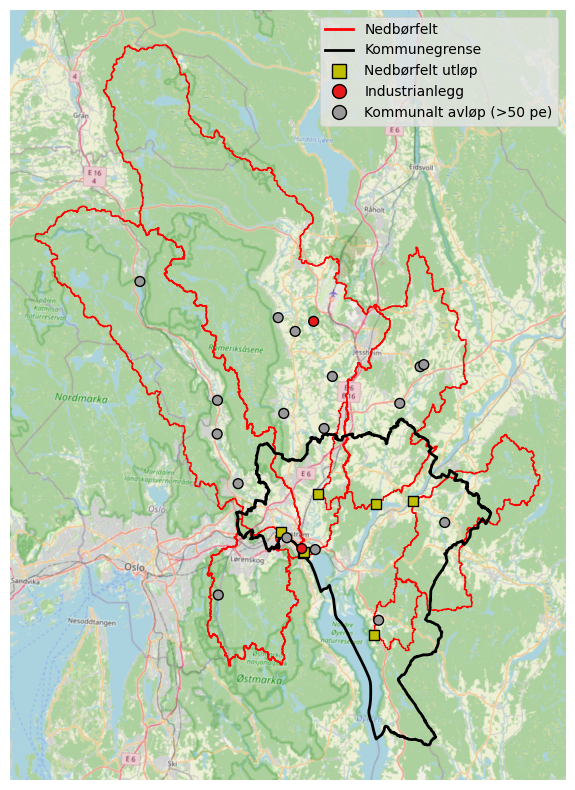

In [12]:
# Plot
fig, ax = plt.subplots(figsize=(10, 10))
cat_gdf.plot(ax=ax, edgecolor="r", facecolor="none", lw=1)
kom_gdf.plot(ax=ax, edgecolor="k", facecolor="none", lw=2)
outlet_gdf.plot(
    ax=ax,
    marker="s",
    edgecolor="k",
    facecolor="y",
    lw=1,
    markersize=50,
)
pt_gdf.plot(
    ax=ax,
    column="sector",
    cmap="Set1",
    legend=True,
    edgecolor="k",
    lw=1,
    markersize=50,
)

# Build legend
legend = ax.get_legend()
for handle in legend.legend_handles:
    try:
        handle.set_markeredgewidth(1)
        handle.set_markeredgecolor("k")
    except AttributeError:
        pass
sector_handles = legend.legend_handles
sector_labels = [t.get_text() for t in legend.texts]
legend.remove()
custom_handles = [
    Line2D([0], [0], color="red", lw=2, label="Nedbørfelt"),
    Line2D([0], [0], color="black", lw=2, label="Kommunegrense"),
    Line2D(
        [0],
        [0],
        marker="s",
        linestyle="None",
        markerfacecolor="y",
        markeredgecolor="k",
        markersize=10,
        label="Nedbørfelt utløp",
    ),
]
all_handles = custom_handles + list(sector_handles)
all_labels = [h.get_label() for h in custom_handles] + sector_labels
ax.legend(all_handles, all_labels, loc="upper right")

# Basemap
cx.add_basemap(
    ax,
    crs=cat_gdf.crs,
    source=cx.providers.OpenStreetMap.Mapnik,
    attribution=False,
)
ax.set_axis_off()

# Save
png_path = r"../plots/catchments_with_point_sources.png"
plt.savefig(png_path, dpi=300, bbox_inches="tight")

### 3.2. Point sources

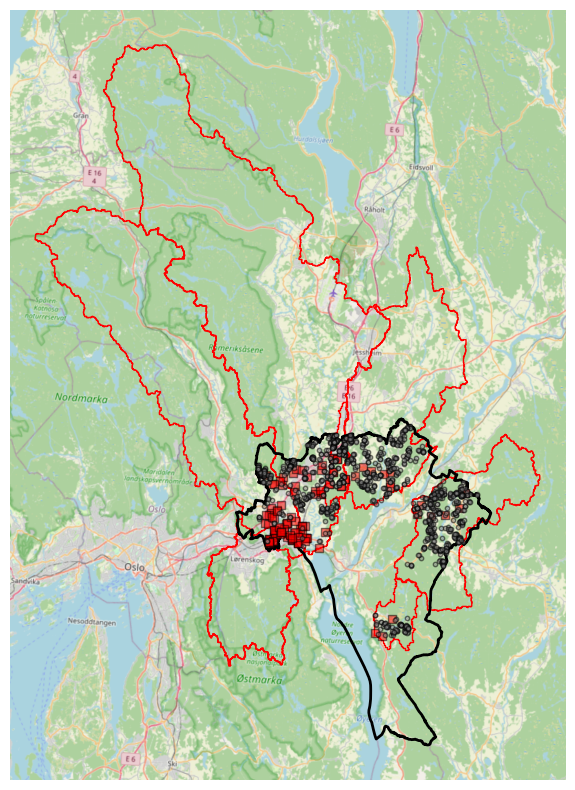

In [13]:
# Plot
fig, ax = plt.subplots(figsize=(10, 10))
cat_gdf.plot(ax=ax, edgecolor="r", facecolor="none", lw=1)
kom_gdf.plot(ax=ax, edgecolor="k", facecolor="none", lw=2)
ov_gdf.plot(
    ax=ax,
    marker="s",
    edgecolor="k",
    facecolor="r",
    lw=1,
    markersize=30,
    alpha=0.5,
)
sp_gdf.plot(
    ax=ax,
    marker="o",
    edgecolor="k",
    facecolor="grey",
    lw=1,
    markersize=10,
    alpha=0.5,
)

# Basemap
cx.add_basemap(
    ax,
    crs=cat_gdf.crs,
    source=cx.providers.OpenStreetMap.Mapnik,
    attribution=False,
)
ax.set_axis_off()

## 4. Land cover

In [ ]:
ar50_gdb = r"/home/jovyan/shared/common/teotil3/core_data/land_cover/nibio_ar50.gdb"
ar50_gdf = gpd.read_file(ar50_gdb, driver="fileGDB", layer="org_ar_ar50_flate")
ar50_gdf_cea = ar50_gdf.to_crs({"proj": "cea"})

In [ ]:
ar50_class_dict = {
    10: "Bebygd",
    20: "Jordbruk",
    30: "Skog",
    50: "Snaumark",
    60: "Myr",
    70: "Bre",
    81: "Ferskvann",
    99: "Ikke kartlagt",
}
color_map = {
    "Bebygd": "#e41a1c",
    "Jordbruk": "#ffff33",
    "Skog": "#4daf4a",
    "Snaumark": "#a65628",
    "Myr": "#984ea3",
    "Bre": "#ffffff",
    "Ferskvann": "#377eb8",
    "Ikke kartlagt": "#bdbdbd",
}

# Intersect
cat_gdf_cea = cat_gdf.to_crs({"proj": "cea"})
bbox = box(*cat_gdf_cea.total_bounds)
ar50_clip = gpd.clip(ar50_gdf_cea, bbox)
int_gdf = gpd.overlay(cat_gdf_cea, ar50_clip, how="intersection", keep_geom_type=True)
int_gdf["area_km2"] = int_gdf.geometry.area / 1e6
int_gdf = int_gdf[int_gdf["artype"] != 82]
int_gdf["klasse"] = int_gdf["artype"].map(ar50_class_dict)
int_gdf["color"] = int_gdf["klasse"].map(color_map)
int_gdf = int_gdf.to_crs("EPSG:25833")

# Land cover props
agg = int_gdf.groupby(["artype", "name", "klasse"], as_index=False)["area_km2"].sum()
lc_df = agg.pivot(index="artype", columns="name", values="area_km2").reset_index()
lc_df["klasse"] = lc_df["artype"].map(ar50_class_dict)
lc_df = lc_df.fillna(0)
cat_cols = [c for c in lc_df.columns if c not in ["artype", "klasse"]]
totals = lc_df[cat_cols].sum(skipna=True)
pct_df = lc_df[cat_cols].div(totals, axis=1) * 100
pct_df.columns = [f"{c}_pct" for c in pct_df.columns]
km2_df = lc_df[cat_cols]
km2_df.columns = [f"{c}_km2" for c in km2_df.columns]
lc_df = pd.concat([lc_df[["klasse"]], km2_df, pct_df], axis=1)
ordered_cols = ["klasse"]
for c in cat_cols:
    ordered_cols.append(f"{c}_km2")
    ordered_cols.append(f"{c}_pct")
lc_df = lc_df[ordered_cols]
lc_df = lc_df.round(1)

# Plot
fig, ax = plt.subplots(figsize=(10, 10))
int_gdf.plot(
    ax=ax,
    color=int_gdf["color"],
    edgecolor="none",
    linewidth=0,
)
cat_gdf.plot(
    ax=ax,
    facecolor="none",
    edgecolor="black",
    linewidth=1,
)
cx.add_basemap(
    ax=ax,
    crs=int_gdf.crs,
    source=cx.providers.CartoDB.Positron,
    attribution=False,
)
present_classes = int_gdf["klasse"].dropna().unique()
legend_elements = [Patch(facecolor=color_map[c], label=c) for c in present_classes]
ax.legend(
    handles=legend_elements,
    title="AR50 klasse",
    loc="upper right",
    ncol=3,
    fontsize=10,
    title_fontsize=12,
)
ax.axis("off")

# Save
png_path = "../plots/catchment_land_cover.png"
plt.savefig(png_path, dpi=300, bbox_inches="tight")
lc_df.to_excel("../data/catchment_land_cover.xlsx", index=False)

lc_df